<h1>Análisis exploratorio de datos y visualizaciones</h1>

Análisis exploratorio de hurtos de automotores en Colombia (2020-2025)

Este notebook explora patrones temporales, geográficos y operativos
relacionados con el hurto de automotores en Colombia entre 2020 y 2025.

In [1]:
!pip install seaborn plotly


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\Prueba\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



In [3]:
df = pd.read_parquet("../data/processed/hurto_automotores_consolidado.parquet")

<h2>Vista general del dataset</h2>

In [4]:
df.head()

,id_registro,departamento,municipio,codigo_dane,armas_medios,fecha_hecho,cantidad
0,1,antioquia,bello,05088000,arma blanca / cortopunzante,2020-01-20,1
1,2,antioquia,bello,05088000,arma blanca / cortopunzante,2020-02-16,1
2,3,antioquia,bello,05088000,arma blanca / cortopunzante,2020-06-22,1
3,4,antioquia,bello,05088000,arma blanca / cortopunzante,2020-12-13,1
4,5,antioquia,copacabana,05212000,arma blanca / cortopunzante,2020-02-15,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43076 entries, 0 to 43075
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_registro   43076 non-null  int64         
 1   departamento  43076 non-null  str           
 2   municipio     43076 non-null  str           
 3   codigo_dane   43076 non-null  str           
 4   armas_medios  43076 non-null  str           
 5   fecha_hecho   43076 non-null  datetime64[us]
 6   cantidad      43076 non-null  Int64         
dtypes: Int64(1), datetime64[us](1), int64(1), str(4)
memory usage: 4.2 MB


In [6]:
df.describe()

,id_registro,fecha_hecho,cantidad
count,43076.000000,43076,43076.0
mean,21538.500000,2023-03-12 21:01:51.319528,1.467128
min,1.000000,2020-01-01 00:00:00,1.0
25%,10769.750000,2021-09-25 00:00:00,1.0
50%,21538.500000,2023-03-24 00:00:00,1.0
75%,32307.250000,2024-09-22 00:00:00,1.0
max,43076.000000,2025-12-31 00:00:00,13.0
std,12435.114435,NaN,1.20641


In [7]:
df.shape

(43076, 7)

<h2>Pregunta 1: Cómo evoluciono el hurto de automotores entre 2020 y 2025</h2>

In [8]:
df["año"] = df["fecha_hecho"].dt.year

hurtos_anuales = (
    df.groupby("año")["cantidad"]
    .sum()
    .reset_index()
)

#agregamos columna con variacion porcentual respecto al año anterior
hurtos_anuales["variacion_pct"] = (
    hurtos_anuales["cantidad"]
    .pct_change() * 100
)

hurtos_anuales

,año,cantidad,variacion_pct
0,2020,9258,<NA>
1,2021,10662,15.165262
2,2022,11151,4.586382
3,2023,11594,3.972738
4,2024,11390,-1.759531
5,2025,9143,-19.727831


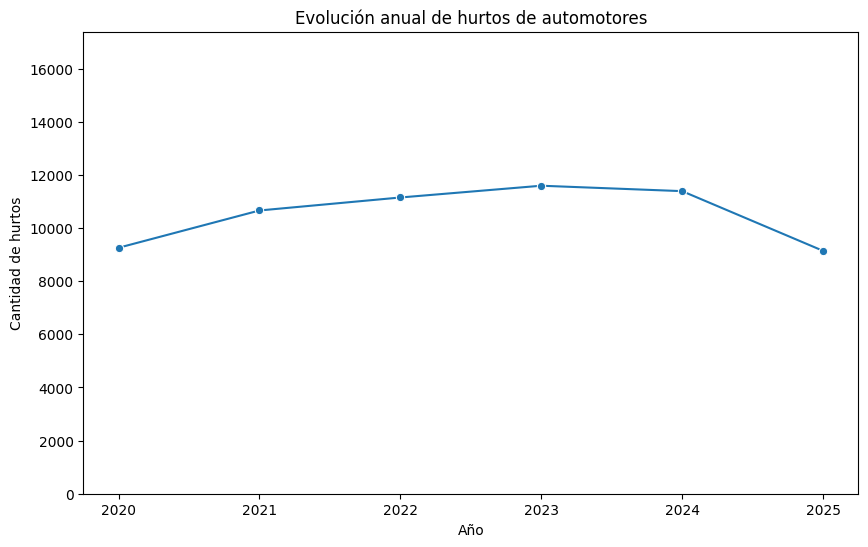

In [9]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=hurtos_anuales,
    x="año",
    y="cantidad",
    marker="o"
)

plt.ylim(0, hurtos_anuales["cantidad"].max() * 1.5)

plt.title("Evolución anual de hurtos de automotores")
plt.xlabel("Año")
plt.ylabel("Cantidad de hurtos")

plt.show()

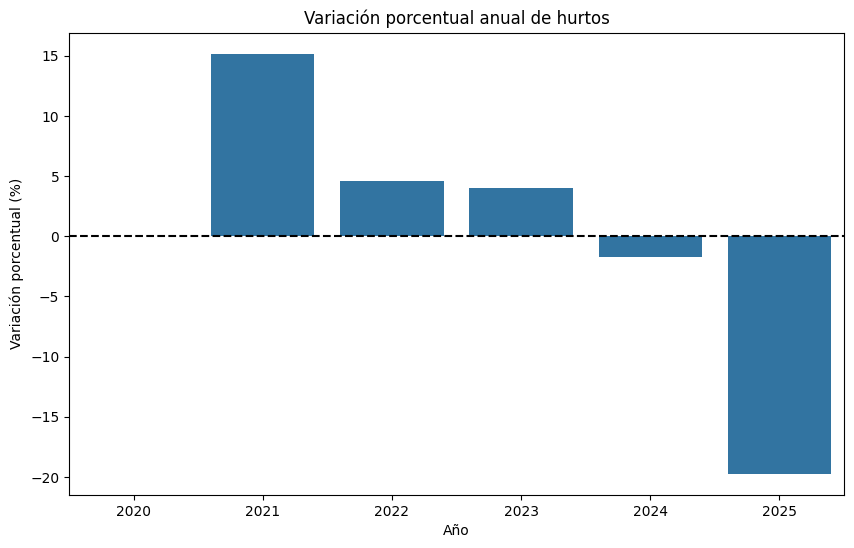

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=hurtos_anuales,
    x="año",
    y="variacion_pct"
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Variación porcentual anual de hurtos")
plt.xlabel("Año")
plt.ylabel("Variación porcentual (%)")

plt.show()

<h3>Interpretacion</h3>

<h2>Pregunta 2: Qué regiones concentran el problema y cómo cambio geográficamente</h2>

<h3>¿Qué departamentos y ciudades/municipios contentran más hurtos?</h3>

In [11]:
hurtos_departamento = (
    df.groupby("departamento")["cantidad"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

hurtos_departamento.head(10)

,departamento,cantidad
0,cundinamarca,26084
1,valle,11794
2,antioquia,9746
3,atlántico,3350
4,cauca,3055
5,nariño,1360
6,norte de santander,1354
7,cesar,1193
8,guajira,961
9,bolívar,673


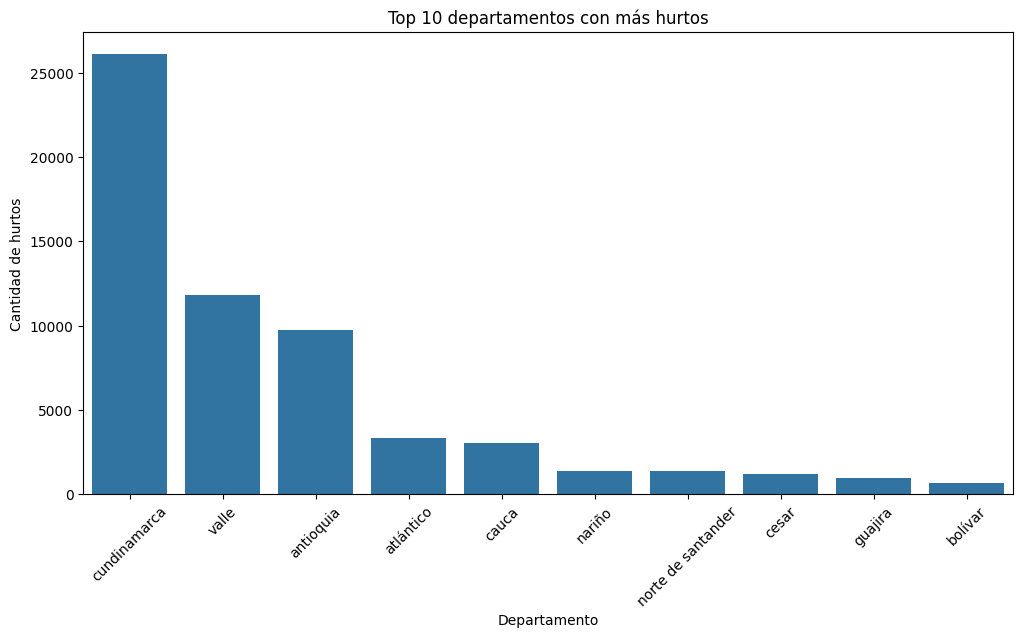

In [12]:
top_10 = hurtos_departamento.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10,
    x="departamento",
    y="cantidad"
)

plt.title("Top 10 departamentos con más hurtos")
plt.xlabel("Departamento")
plt.ylabel("Cantidad de hurtos")

plt.xticks(rotation=45)

plt.show()

In [13]:
hurtos_municipio = (
    df.groupby("municipio")["cantidad"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

hurtos_municipio.head(10)

,municipio,cantidad
0,bogotá d.c. (ct),22664
1,cali (ct),9708
2,medellín (ct),5856
3,barranquilla (ct),2369
4,soacha,1315
5,popayán (ct),1285
6,bello,1247
7,cúcuta (ct),546
8,ipiales,535
9,cartagena (ct),515


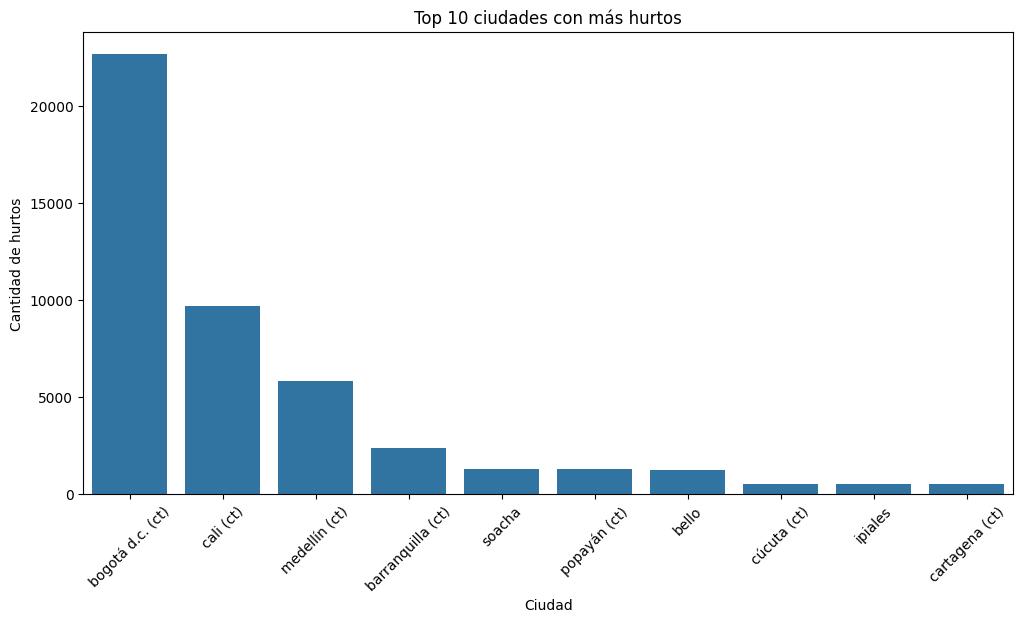

In [14]:
top_10 = hurtos_municipio.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10,
    x="municipio",
    y="cantidad"
)

plt.title("Top 10 ciudades con más hurtos")
plt.xlabel("Ciudad")
plt.ylabel("Cantidad de hurtos")

plt.xticks(rotation=45)

plt.show()

<h3>¿Cómo cambio geográficamente?</h3>

<h4>Por departamento</h4>

In [15]:
departamento_año = (
    df.groupby(["año", "departamento"])["cantidad"]
    .sum()
    .reset_index()
)

departamento_año.head(5)

,año,departamento,cantidad
0,2020,antioquia,1467
1,2020,arauca,71
2,2020,atlántico,294
3,2020,bolívar,77
4,2020,boyacá,24


In [16]:
top_departamentos = (
    hurtos_departamento
    .head(5)["departamento"]
)

filtro = departamento_año[
    departamento_año["departamento"]
    .isin(top_departamentos)
]

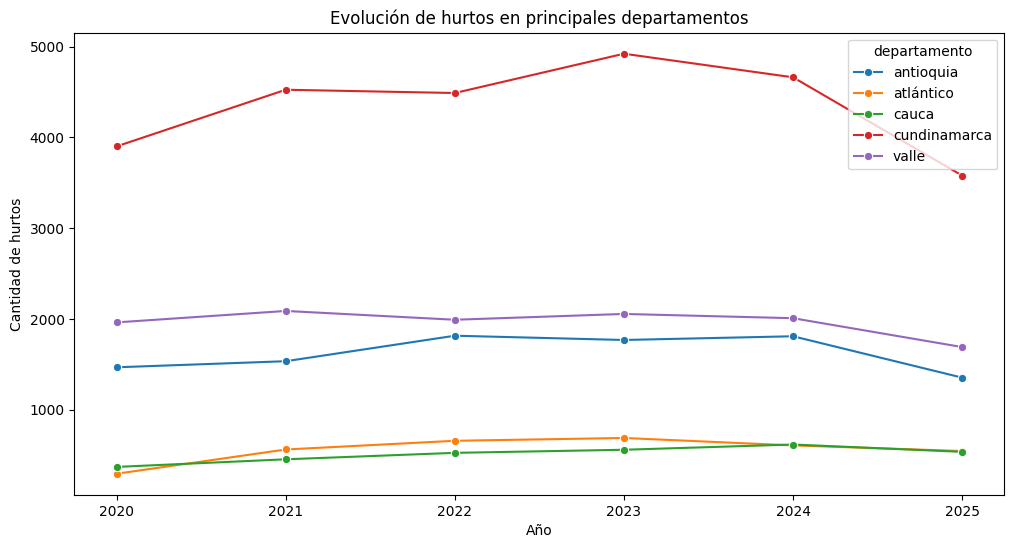

In [17]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=filtro,
    x="año",
    y="cantidad",
    hue="departamento",
    marker="o"
)

plt.title("Evolución de hurtos en principales departamentos")
plt.xlabel("Año")
plt.ylabel("Cantidad de hurtos")

plt.show()

<h4>Por ciudad/municipio</h4>

In [18]:
ciudad_año = (
    df.groupby(["año", "municipio"])["cantidad"]
    .sum()
    .reset_index()
)

ciudad_año.head(5)

,año,municipio,cantidad
0,2020,abrego,4
1,2020,acacías,5
2,2020,aguachica,16
3,2020,agustín codazzi,9
4,2020,aipe,1


In [19]:
top_ciudades = (
    hurtos_municipio
    .head(5)["municipio"]
)

filtro = ciudad_año[
    ciudad_año["municipio"]
    .isin(top_ciudades)
]

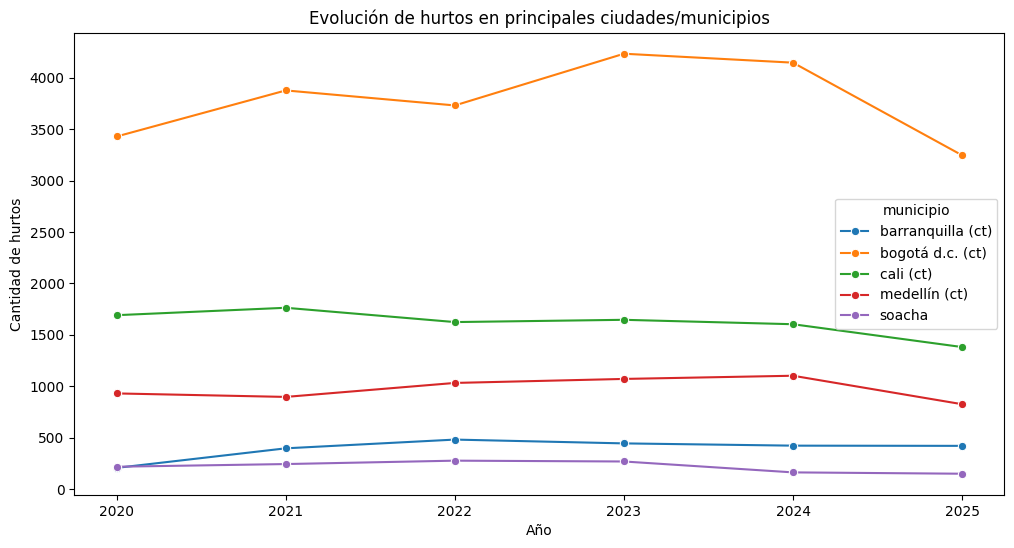

In [20]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=filtro,
    x="año",
    y="cantidad",
    hue="municipio",
    marker="o"
)

plt.title("Evolución de hurtos en principales ciudades/municipios")
plt.xlabel("Año")
plt.ylabel("Cantidad de hurtos")

plt.show()

Ahora comparamos los principales ciudades por año, el análisis anterior conteba con el acumulado de los 6 años analizados, ahora veremos el cambio en cada año 

In [21]:
departamento_año["ranking"] = (
    departamento_año
    .groupby("año")["cantidad"]
    .rank(method="dense", ascending=False)
)

In [22]:
top5_por_año = departamento_año[
    departamento_año["ranking"] <= 5
]

In [23]:
top5_por_año.sort_values(
    ["año", "ranking"]
)

,año,departamento,cantidad,ranking
11,2020,cundinamarca,3902,1.0
26,2020,valle,1962,2.0
0,2020,antioquia,1467,3.0
8,2020,cauca,369,4.0
2,2020,atlántico,294,5.0
38,2021,cundinamarca,4526,1.0
52,2021,valle,2088,2.0
27,2021,antioquia,1534,3.0
29,2021,atlántico,561,4.0
35,2021,cauca,453,5.0


<Axes: xlabel='año', ylabel='departamento'>

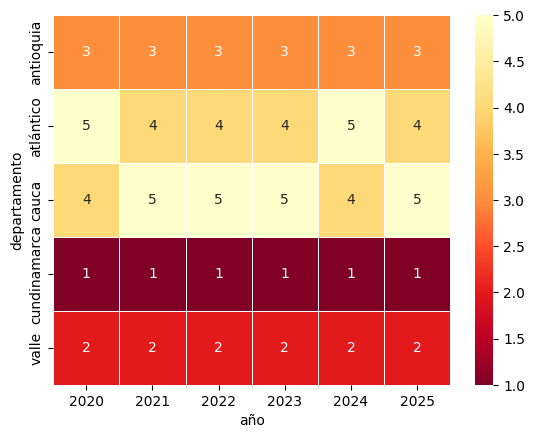

In [24]:
heatmap_df = top5_por_año.pivot(
    index="departamento",
    columns="año",
    values="ranking"
)

heatmap_df

heatmap_df = heatmap_df.astype("float64")

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="YlOrRd_r",
    linewidths=0.5
)

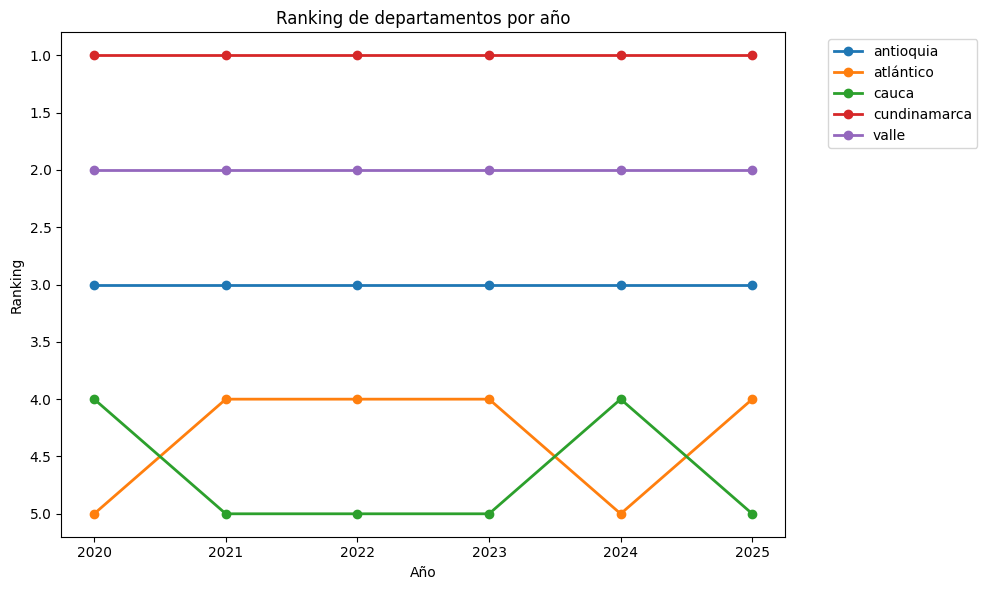

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for departamento in heatmap_df.index:
    
    plt.plot(
        heatmap_df.columns,
        heatmap_df.loc[departamento],
        marker="o",
        linewidth=2,
        label=departamento
    )

plt.gca().invert_yaxis()

plt.title("Ranking de departamentos por año")
plt.xlabel("Año")
plt.ylabel("Ranking")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

Ahora por ciudad

In [26]:
ciudad_año["ranking"] = (
    ciudad_año
    .groupby("año")["cantidad"]
    .rank(method="dense", ascending=False)
)

top5_por_año_ciudad = ciudad_año[
    ciudad_año["ranking"] <= 5
]

top5_por_año_ciudad.sort_values(
    ["año", "ranking"]
)

,año,municipio,cantidad,ranking
37,2020,bogotá d.c. (ct),3429,1.0
52,2020,cali (ct),1691,2.0
198,2020,medellín (ct),930,3.0
327,2020,soacha,217,4.0
32,2020,barranquilla (ct),206,5.0
433,2021,bogotá d.c. (ct),3877,1.0
451,2021,cali (ct),1763,2.0
618,2021,medellín (ct),896,3.0
430,2021,barranquilla (ct),396,4.0
764,2021,soacha,243,5.0


<Axes: xlabel='año', ylabel='municipio'>

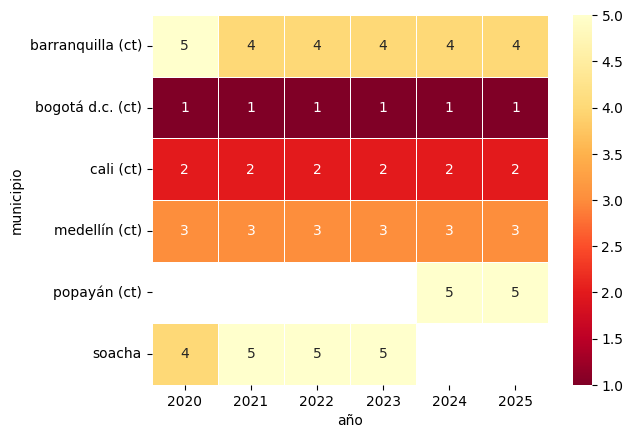

In [27]:
heatmap_df_ciudad = top5_por_año_ciudad.pivot(
    index="municipio",
    columns="año",
    values="ranking"
)

heatmap_df_ciudad

heatmap_df_ciudad = heatmap_df_ciudad.astype("float64")

sns.heatmap(
    heatmap_df_ciudad,
    annot=True,
    cmap="YlOrRd_r",
    linewidths=0.5
)

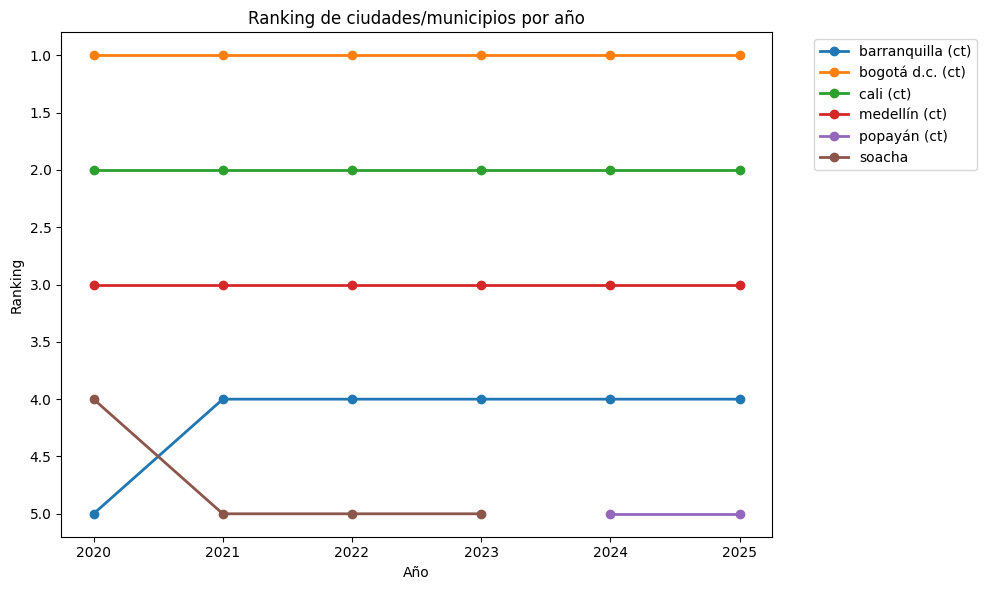

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for municipio in heatmap_df_ciudad.index:
    
    plt.plot(
        heatmap_df_ciudad.columns,
        heatmap_df_ciudad.loc[municipio],
        marker="o",
        linewidth=2,
        label=municipio
    )

plt.gca().invert_yaxis()

plt.title("Ranking de ciudades/municipios por año")
plt.xlabel("Año")
plt.ylabel("Ranking")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

<h2>Pregunta 3: ¿Qué patrones temporales aparecen en meses, días y temporadas?</h2>

In [29]:
df['mes'] = df['fecha_hecho'].dt.month
orden_meses = [
    "Enero",
    "Febrero",
    "Marzo",
    "Abril",
    "Mayo",
    "Junio",
    "Julio",
    "Agosto",
    "Septiembre",
    "Octubre",
    "Noviembre",
    "Diciembre"
]

df["nombre_mes"] = pd.Categorical(
    df["nombre_mes"],
    categories=orden_meses,
    ordered=True
)

resultado = (
    df.groupby("nombre_mes")["cantidad"]
    .sum()
)

KeyError: 'nombre_mes'

In [ ]:
# Cuenta cuántos elementos hay en 'otra_columna' por cada mes
resultado = df.groupby('nombre_mes')['cantidad'].sum()
resultado

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(resultado.index, resultado.values, marker="o")

plt.title("Hurtos de automotores por mes (2020-2025)")
plt.xlabel("Mes")
plt.ylabel("Cantidad")

plt.show()

In [ ]:
mes_año = (
    df.groupby(["año","mes"])["cantidad"]
    .sum()
    .reset_index()
)

pivot_mes = mes_año.pivot(
    index="mes",
    columns="año",
    values="cantidad"
)

pivot_mes.head()


In [ ]:
plt.figure(figsize=(14,12))

meses = [
    "Ene","Feb","Mar","Abr",
    "May","Jun","Jul","Ago",
    "Sep","Oct","Nov","Dic"
]

plt.xticks(range(1,13), meses)

for año in pivot_mes.columns:

    plt.plot(
        pivot_mes.index,
        pivot_mes[año],
        marker="o",
        linewidth=2,
        label=año
    )

plt.title("Hurtos de automotores por mes y año")
plt.xlabel("Mes")
plt.ylabel("Cantidad")

plt.legend(title="Año")

plt.show()



In [ ]:
plt.figure(figsize=(14,4))

sns.barplot(
    x=resultado.index,
    y=resultado.values
)

plt.title("Hurtos de automotores por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad")

plt.show()

In [ ]:
mes_año = (
    df.groupby(["año","mes"])["cantidad"]
    .sum()
    .reset_index()
)

heatmap_mes = mes_año.pivot(
    index="año",
    columns="mes",
    values="cantidad"
)

In [ ]:
plt.figure(figsize=(12,5))

heatmap_mes = heatmap_mes.astype("float64")

sns.heatmap(
    heatmap_mes,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)

plt.title("Hurtos por año y mes")

plt.show()

In [ ]:
df['dia_semana'] = df['fecha_hecho'].dt.day_name()
resultado_dia = df.groupby('dia_semana')['cantidad'].count()
resultado_dia.sort_values(ascending=False)

<h2>Pregunta 4: ¿Cómo cambió el modus operandi del delito?</h2>

cuales son las modalidades mas utilizadas en todo el periodo

In [45]:
df_armas = df.groupby(["armas_medios"])["cantidad"].count()
df_armas

armas_medios
arma blanca / cortopunzante      861
arma de fuego                  12720
contundentes                     181
escopolamina                     480
llave maestra                   9908
no reportado                     443
sin empleo de armas            18483
Name: cantidad, dtype: Int64

In [46]:

df_armas = df.groupby(["armas_medios", "año"])["cantidad"].count()
df_armas

armas_medios                 año 
arma blanca / cortopunzante  2020     140
                             2021     152
                             2022     120
                             2023     159
                             2024     163
                             2025     127
arma de fuego                2020    1758
                             2021    2361
                             2022    1971
                             2023    2151
                             2024    2109
                             2025    2370
contundentes                 2020      25
                             2021      32
                             2022      32
                             2023      26
                             2024      38
                             2025      28
escopolamina                 2020      77
                             2021     111
                             2022      95
                             2023      78
                             2024      75


participacion porcentual por año

In [47]:
df_armas = df.groupby([ "año","armas_medios",])["cantidad"].count()
df_armas

año   armas_medios               
2020  arma blanca / cortopunzante     140
      arma de fuego                  1758
      contundentes                     25
      escopolamina                     77
      llave maestra                  1147
      no reportado                    275
      sin empleo de armas            1851
2021  arma blanca / cortopunzante     152
      arma de fuego                  2361
      contundentes                     32
      escopolamina                    111
      llave maestra                  1661
      no reportado                     11
      sin empleo de armas            3392
2022  arma blanca / cortopunzante     120
      arma de fuego                  1971
      contundentes                     32
      escopolamina                     95
      llave maestra                  1436
      no reportado                     19
      sin empleo de armas            3064
2023  arma blanca / cortopunzante     159
      arma de fuego                  2151


In [48]:
df_proporcion = (df_armas / df_armas.groupby("año").transform("sum"))*100

In [49]:
df_proporcion

año   armas_medios               
2020  arma blanca / cortopunzante     2.655035
      arma de fuego                  33.339655
      contundentes                    0.474113
      escopolamina                    1.460269
      llave maestra                  21.752323
      no reportado                    5.215247
      sin empleo de armas            35.103357
2021  arma blanca / cortopunzante     1.968912
      arma de fuego                  30.582902
      contundentes                    0.414508
      escopolamina                    1.437824
      llave maestra                  21.515544
      no reportado                    0.142487
      sin empleo de armas            43.937824
2022  arma blanca / cortopunzante     1.781208
      arma de fuego                  29.256346
      contundentes                    0.474989
      escopolamina                    1.410123
      llave maestra                  21.315125
      no reportado                    0.282025
      sin empleo de armas 